# Data Collection and Preprocessing for Graduation Project

## 📚 Learning Objectives

By completing this notebook, you will:
- Collect and acquire datasets for graduation project
- Perform comprehensive data cleaning and preprocessing
- Implement feature engineering techniques
- Validate data quality and create train/validation/test splits
- Document data collection and preprocessing procedures

## 🔗 Prerequisites

- ✅ Unit 1: Project proposal completed
- ✅ Unit 2: System design for your project drafted
- ✅ Understanding of data science pipelines
- ✅ Python, Pandas, NumPy knowledge

---

This notebook covers practical activities from **Course 12, Unit 3**:
- Collecting and acquiring datasets
- Performing data cleaning and preprocessing using Python libraries
- Implementing feature engineering techniques
- Validating data quality and preparing train/validation/test splits
- Creating data exploration notebooks with visualizations

---

## Introduction

**Data Collection and Preparation** is critical for project success. Quality data leads to quality models.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: import the preprocessing toolkit — pandas/NumPy for the data itself,
# matplotlib/seaborn for the EDA plots, and scikit-learn's split/scale/encode
# utilities used by the cleaning pipeline below.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Confirm the environment is ready before the pipeline cells run
print("✅ Libraries imported!")
print("Ready for data collection and preprocessing!")


✅ Libraries imported!
Ready for data collection and preprocessing!


## Part 1: Data Collection Strategies

Explore different data sources and collection methods.


In [2]:
# Map of data-collection strategies: for each source type, what it offers and
# what to watch out for — choosing a realistic, legally usable data source is
# the first real decision of the capstone, and licensing or ethics problems
# are far cheaper to catch now than after you have built on the data.
print("=" * 60)
print("Data Collection Strategies")
print("=" * 60)

# Four families of sources, each with concrete examples, advantages, and caveats
data_sources = {
    "Public Datasets": {
        "sources": [
            "Kaggle Datasets", "UCI Machine Learning Repository",
            "Google Dataset Search",
            "Papers with Code Datasets",
            "Hugging Face Datasets"
        ],
        "advantages": "Ready to use, often cleaned, documented",
        "considerations": "Check licensing, ensure relevance to your problem"
    },
    "APIs": {
        "sources": [
            "Twitter API (for social media analysis)",
            "Reddit API",
            "News APIs",
            "Government data APIs"
        ],
        "advantages": "Real-time data, structured format",
        "considerations": "API limits, authentication, rate limiting"
    },
    "Web Scraping": {
        "sources": [
            "BeautifulSoup + requests",
            "Scrapy framework",
            "Selenium for dynamic content"
        ],
        "advantages": "Access to large amounts of data",
        "considerations": "Legal and ethical considerations, robots.txt, ToS"
    },
    "Custom Collection": {
        "sources": [
            "Surveys",
            "Experiments",
            "Sensors/IoT devices"
        ],
        "advantages": "Tailored to your specific needs",
        "considerations": "Time-consuming, requires IRB approval for human subjects"
    }
}

# Print a compact card per strategy so the trade-offs sit side by side
for source_type, details in data_sources.items():
    print(f"\n{source_type}:")
    print(f"  Sources: {', '.join(details['sources'][:3])}...")
    print(f"  Advantages: {details['advantages']}")
    print(f"  Considerations: {details['considerations']}")

print("\n✅ Choose data sources aligned with your project goals and ethical guidelines!")


Data Collection Strategies

Public Datasets:
  Sources: Kaggle Datasets, UCI Machine Learning Repository, Google Dataset Search...
  Advantages: Ready to use, often cleaned, documented
  Considerations: Check licensing, ensure relevance to your problem

APIs:
  Sources: Twitter API (for social media analysis), Reddit API, News APIs...
  Advantages: Real-time data, structured format
  Considerations: API limits, authentication, rate limiting

Web Scraping:
  Sources: BeautifulSoup + requests, Scrapy framework, Selenium for dynamic content...
  Advantages: Access to large amounts of data
  Considerations: Legal and ethical considerations, robots.txt, ToS

Custom Collection:
  Sources: Surveys, Experiments, Sensors/IoT devices...
  Advantages: Tailored to your specific needs
  Considerations: Time-consuming, requires IRB approval for human subjects

✅ Choose data sources aligned with your project goals and ethical guidelines!


## Part 2: Data Cleaning and Preprocessing Pipeline

Comprehensive data cleaning workflow.


In [3]:
# Build and run a full cleaning pipeline on a small synthetic dataset so every
# step (inspect -> impute -> encode -> scale) is visible in one place.
# Generate sample data for demonstration (1000 rows, one column with ~5% missing)
np.random.seed(42)
sample_data = pd.DataFrame({
    'feature1': np.random.randn(1000), 'feature2': np.random.choice(['A', 'B', 'C'], 1000),
    'feature3': np.random.randn(1000) + np.random.choice([0, np.nan], 1000, p=[0.95, 0.05]),
    'target': np.random.choice([0, 1], 1000)
})

print("=" * 60)
print("Data Cleaning Pipeline")
print("=" * 60)

print("\n1. Initial Data Inspection:")
print(f"   Shape: {sample_data.shape}")
print(f"   Missing values:\n{sample_data.isnull().sum()}")

# Handle missing values
print("\n2. Handling Missing Values:")
# Option 1: Drop rows with missing values
data_dropped = sample_data.dropna()
print(f"   After dropping: {data_dropped.shape}")

# Option 2: Fill missing values (mean for numeric, mode for categorical)
data_filled = sample_data.copy()
data_filled['feature3'] = data_filled['feature3'].fillna(data_filled['feature3'].mean())
print(f"   After filling: Missing values = {data_filled.isnull().sum().sum()}")

# Handle categorical variables
print("\n3. Encoding Categorical Variables:")
le = LabelEncoder()
data_encoded = data_filled.copy()
data_encoded['feature2_encoded'] = le.fit_transform(data_encoded['feature2'])
print(f"   Original categories: {data_filled['feature2'].unique()}")
print(f"   Encoded values: {data_encoded['feature2_encoded'].unique()}")

# Feature scaling
print("\n4. Feature Scaling:")
scaler = StandardScaler()
numeric_features = ['feature1', 'feature3']
data_scaled = data_encoded.copy()
data_scaled[numeric_features] = scaler.fit_transform(data_scaled[numeric_features])
print(f"   Features scaled: {numeric_features}")
print(f"   Mean after scaling: {data_scaled[numeric_features].mean().round(4).tolist()}")
print(f"   Std after scaling: {data_scaled[numeric_features].std().round(4).tolist()}")

print("\n✅ Data cleaning pipeline complete!")


Data Cleaning Pipeline

1. Initial Data Inspection:
   Shape: (1000, 4)
   Missing values:
feature1     0
feature2     0
feature3    43
target       0
dtype: int64

2. Handling Missing Values:
   After dropping: (957, 4)
   After filling: Missing values = 0

3. Encoding Categorical Variables:
   Original categories: ['C' 'A' 'B']
   Encoded values: [2 0 1]

4. Feature Scaling:
   Features scaled: ['feature1', 'feature3']
   Mean after scaling: [0.0, 0.0]
   Std after scaling: [1.0005, 1.0005]

✅ Data cleaning pipeline complete!


### Exploratory Data Analysis (EDA) Visualizations

Before modeling, *look* at the data. Quick plots catch problems that summary
numbers hide: skewed distributions, dominant categories, and imputation
artifacts. Build plots like these for your own project dataset.

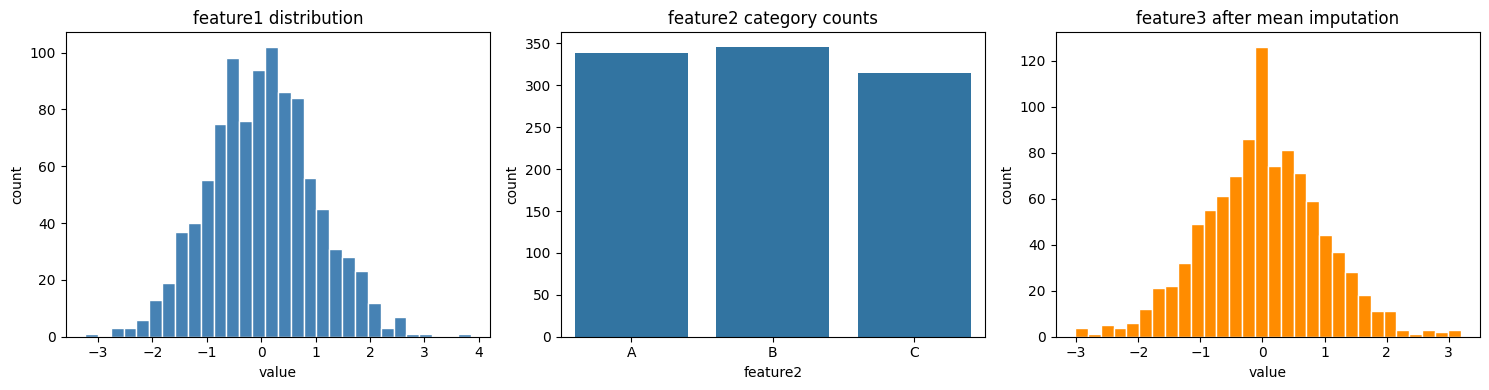

✅ EDA figures rendered — always look at distributions before you model!


In [4]:
# EDA visualizations: plot the data BEFORE modeling so surprises (skew,
# category imbalance, imputation artifacts) are caught early, not after training.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of feature1: shows the shape of a numeric feature (outliers, skew)
axes[0].hist(data_filled['feature1'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('feature1 distribution')
axes[0].set_xlabel('value')
axes[0].set_ylabel('count')

# Bar chart of feature2 counts: reveals rare or dominant categories
sns.countplot(x='feature2', data=data_filled, order=['A', 'B', 'C'], ax=axes[1])
axes[1].set_title('feature2 category counts')

# Histogram of feature3 after imputation: sanity-check the mean-fill step
axes[2].hist(data_filled['feature3'], bins=30, color='darkorange', edgecolor='white')
axes[2].set_title('feature3 after mean imputation')
axes[2].set_xlabel('value')
axes[2].set_ylabel('count')

# Render all three panels side by side
plt.tight_layout()
plt.show()

print('✅ EDA figures rendered — always look at distributions before you model!')

### Feature Engineering

Cleaning makes data *usable*; feature engineering makes it *informative*.
Below we build two new features from the existing columns — an interaction
term and a quartile bin — the same techniques you can apply to your own
project data.

In [5]:
# Feature engineering: create NEW columns from existing ones so the model
# gets signals the raw features do not expose directly.
data_features = data_scaled.copy()

# Interaction feature: the product of two numeric features
data_features['feature1_x_feature3'] = data_features['feature1'] * data_features['feature3']

# Binned feature: which quartile of feature1 each row falls in (ordinal code 0-3)
data_features['feature1_bin'] = pd.qcut(data_features['feature1'], q=4, labels=False)

# Show the engineered columns next to the source columns they came from
print('=' * 60)
print('Engineered Features')
print('=' * 60)
print(data_features[['feature1', 'feature3', 'feature1_x_feature3', 'feature1_bin']].head())
print(f"\nColumns now available: {list(data_features.columns)}")
print('\n✅ Feature engineering complete — 2 new features created!')

Engineered Features
   feature1  feature3  feature1_x_feature3  feature1_bin
0  0.487759  0.138200             0.067408             2
1 -0.161022 -1.857353             0.299075             1
2  0.642015  0.328714             0.211039             2
3  1.536382 -0.163317            -0.250918             3
4 -0.258995 -0.496132             0.128496             1

Columns now available: ['feature1', 'feature2', 'feature3', 'target', 'feature2_encoded', 'feature1_x_feature3', 'feature1_bin']

✅ Feature engineering complete — 2 new features created!


## Part 3: Train/Validation/Test Split

Proper data splitting for model development and evaluation.


In [6]:
# Split the prepared data into train/validation/test sets so tuning and the
# final evaluation each get data the model has never seen.
# Features: the cleaned columns plus the two engineered ones from the previous cell
feature_cols = ['feature1', 'feature3', 'feature2_encoded', 'feature1_x_feature3', 'feature1_bin']
X = data_features[feature_cols]
y = data_features['target']

# Split: 60% train, 20% validation, 20% test (stratified keeps class balance)
# First carve off the test set, then split the rest into train and validation
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Report the sizes so the 60/20/20 ratio is visible
print("=" * 60)
print("Data Splitting Strategy")
print("=" * 60)
print(f"Total samples: {len(X)}")
print(f"Training set: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print("\n✅ Data split complete!")
print("📝 Use validation set for hyperparameter tuning")
print("📝 Use test set ONLY for final evaluation")

Data Splitting Strategy
Total samples: 1000
Training set: 600 (60.0%)
Validation set: 200 (20.0%)
Test set: 200 (20.0%)

✅ Data split complete!
📝 Use validation set for hyperparameter tuning
📝 Use test set ONLY for final evaluation


## Summary

### Key Steps in Data Collection & Preparation:
1. **Data Collection**: Identify and acquire relevant datasets
2. **Data Inspection**: Understand data structure, types, distributions
3. **Data Cleaning**: Handle missing values, outliers, inconsistencies
4. **Feature Engineering**: Create meaningful features from raw data
5. **Data Splitting**: Train/Validation/Test sets (60/20/20 or 70/15/15)
6. **Documentation**: Document all preprocessing steps for reproducibility

### Best Practices:
- Always check data quality before modeling
- Document all preprocessing steps
- Save cleaned datasets for reproducibility
- Use stratified splitting for imbalanced data
- Validate data representativeness

**Reference:** Course 12, Unit 3: "Implementation and Development of the Project Idea" — the data pipeline above (collection strategy, cleaning, EDA visualizations, feature engineering, splitting) is demonstrated on a synthetic dataset; apply each step to your own project data.


## 📚 References

1. Wickham, H. (2014). *Tidy Data*. Journal of Statistical Software, 59(10), 1–23. <https://doi.org/10.18637/jss.v059.i10>
2. Gebru, T., Morgenstern, J., Vecchione, B., et al. (2021). *Datasheets for Datasets*. Communications of the ACM, 64(12). <https://arxiv.org/abs/1803.09010>
3. Sambasivan, N., Kapania, S., Highfill, H., et al. (2021). *"Everyone wants to do the model work, not the data work": Data Cascades in High-Stakes AI*. CHI 2021. <https://doi.org/10.1145/3411764.3445518>